## Iteration 2

### Preprocessing

For the next iteration, I plan to boost the accuracy of the model by incorporating data augmentation techniques. Data augmentation involves applying various transformations to the existing dataset, effectively enlarging its size and enhancing its diversity. By exposing the model to a broader range of data variations, I aim to improve its ability to generalize and reduce overfitting.

To implement this, I will utilize Keras' ImageDataGenerator, which offers powerful capabilities for generating augmented image data. By configuring parameters such as rotation, shifting, shearing, zooming, and flipping, I can create a more comprehensive dataset that better represents real-world scenarios.

Applying onhot encoding

In [522]:
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoded vectors
v2_y_train_onehot = to_categorical(y_train)
v2_y_val_onehot = to_categorical(y_val)
v2_y_test_onehot = to_categorical(y_test)

In [523]:
v2_X_train = X_train
v2_y_train = v2_y_train_onehot
v2_X_val = X_val
v2_y_val = v2_y_val_onehot
v2_X_test = X_test
v2_y_test = v2_y_test_onehot

The below code showcases how the pictures look like without data augmentation 

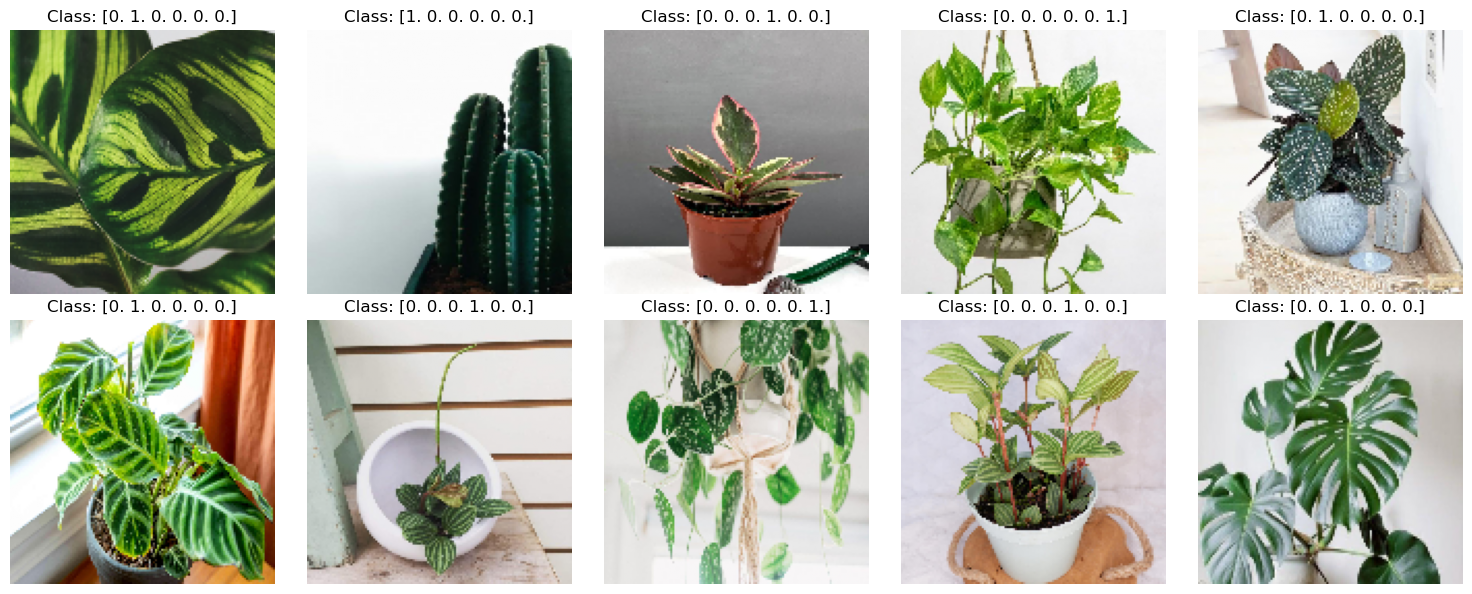

In [524]:
import matplotlib.pyplot as plt
import numpy as np

# Display original images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    img_index = np.random.randint(len(v2_X_train))
    axes[i].imshow(X_train[img_index])
    axes[i].set_title(f"Class: {v2_y_train[img_index]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


Applying sharpening filter using OpenCV, to enhance the features each plant contains.

In [525]:
# Define custom data augmentation function
def custom_augmentation(image):
    # Apply sharpen filter using OpenCV
    kernel = np.array([[0, -1, 0], 
                       [-1, 5, -1], 
                       [0, -1, 0]], dtype=np.float32)
    sharpened_image = cv2.filter2D(image, -1, kernel)
    return sharpened_image

Applying data augmentation using ImageDataGenerator

In [526]:
from keras.preprocessing.image import ImageDataGenerator

# Define the augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='reflect',
    preprocessing_function=custom_augmentation)

# Fit the data generator to training data
datagen.fit(v2_X_train)

# Generate augmented data
augmented_data = datagen.flow(v2_X_train, v2_y_train, batch_size=100)

In [527]:
# Generate augmented data
augmented_data = datagen.flow(v2_X_train, v2_y_train, batch_size=len(v2_X_train), shuffle=False)

# Get augmented images and labels
augmented_images, augmented_labels = next(augmented_data)

# Concatenate augmented data with original training data
X_train_augmented = np.concatenate((v2_X_train, augmented_images))
y_train_augmented = np.concatenate((v2_y_train, augmented_labels))


Images after data augmentation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


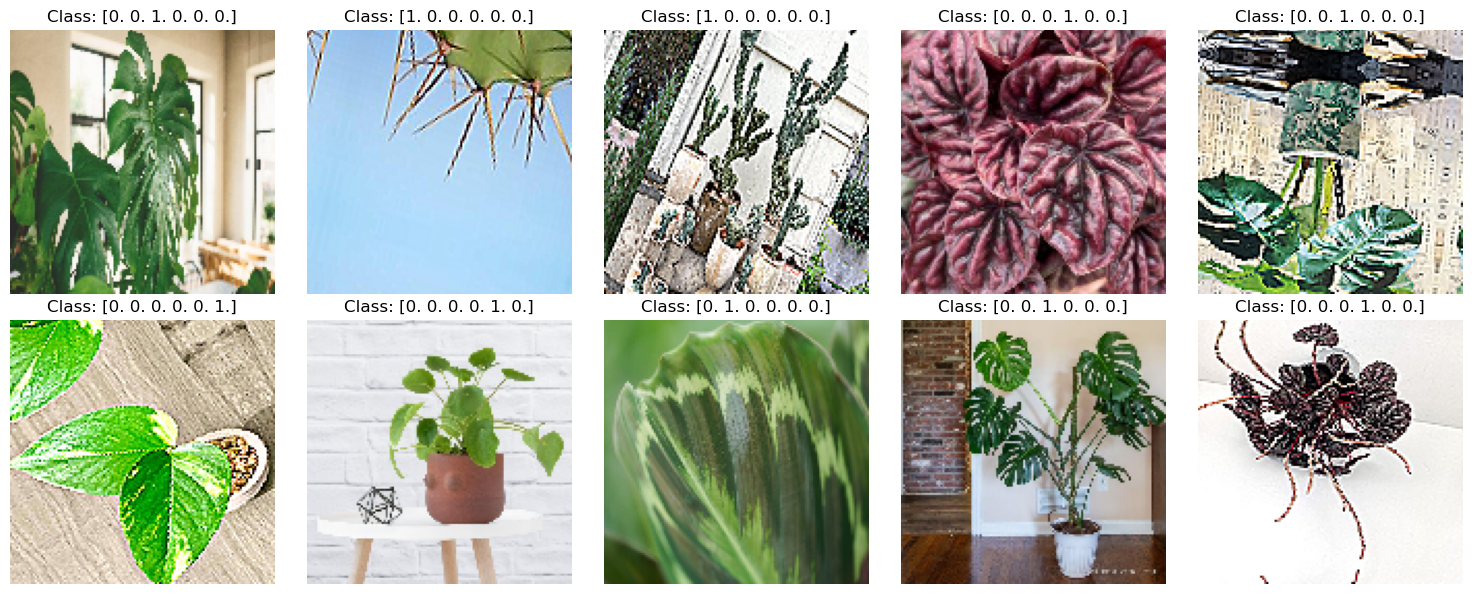

In [528]:
# Shuffle the augmented data
shuffle_indices = np.random.permutation(len(X_train_augmented))
v2_X_train = X_train_augmented[shuffle_indices]
v2_y_train = y_train_augmented[shuffle_indices]

# Display augmented images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    idx = shuffle_indices[i]  # Random index
    axes[i].imshow(v2_X_train[idx])
    axes[i].set_title(f"Class: {v2_y_train[idx]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### CNN Architecture

In the first iteration, I observed that implementing Dropout and Batch normalization did not enhance the architecture; instead, it made the process time-consuming. Therefore, I decided to omit the use of Dropout and Batch normalization in this phase and concentrate on improving the architecture through data augmentation.

In [529]:
# Define your model
v2_model = Sequential()

v2_model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)))
v2_model.add(MaxPooling2D())
v2_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
v2_model.add(MaxPooling2D())
v2_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
v2_model.add(MaxPooling2D())
v2_model.add(Dense(64, activation='relu'))
v2_model.add(MaxPooling2D())
v2_model.add(MaxPooling2D())
v2_model.add(Dense(64, activation='relu'))
v2_model.add(MaxPooling2D())
v2_model.add(Flatten())
v2_model.add(Dense(256, activation='relu'))
v2_model.add(Dense(6, activation='softmax'))

In [530]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [531]:
v2_model.compile('adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [532]:
v2_model.summary()

Model: "sequential_60"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_109 (Conv2D)         (None, 126, 126, 256)     7168      
                                                                 
 max_pooling2d_133 (MaxPooli  (None, 63, 63, 256)      0         
 ng2D)                                                           
                                                                 
 conv2d_110 (Conv2D)         (None, 61, 61, 128)       295040    
                                                                 
 max_pooling2d_134 (MaxPooli  (None, 30, 30, 128)      0         
 ng2D)                                                           
                                                                 
 conv2d_111 (Conv2D)         (None, 28, 28, 128)       147584    
                                                                 
 max_pooling2d_135 (MaxPooli  (None, 14, 14, 128)    

### CNN Training

In [533]:
# Train the model
v2_history = v2_model.fit(v2_X_train, v2_y_train, epochs=150, batch_size=64, validation_data=(v2_X_val, v2_y_val), callbacks=[early_stopping])

# Evaluate the model on the test set
test_loss, test_accuracy = v2_model.evaluate(v2_X_test, v2_y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/150
27/27 [==============================] - 45s 2s/step - loss: 1.7945 - accuracy: 0.1655 - val_loss: 1.7913 - val_accuracy: 0.1833
Epoch 2/150
27/27 [==============================] - 43s 2s/step - loss: 1.7900 - accuracy: 0.1815 - val_loss: 1.7933 - val_accuracy: 0.1583
Epoch 3/150
27/27 [==============================] - 44s 2s/step - loss: 1.7251 - accuracy: 0.2435 - val_loss: 1.7131 - val_accuracy: 0.2333
Epoch 4/150
27/27 [==============================] - 44s 2s/step - loss: 1.6545 - accuracy: 0.2792 - val_loss: 1.6547 - val_accuracy: 0.3125
Epoch 5/150
27/27 [==============================] - 44s 2s/step - loss: 1.6182 - accuracy: 0.2929 - val_loss: 1.6417 - val_accuracy: 0.2792
Epoch 6/150
27/27 [==============================] - 47s 2s/step - loss: 1.5857 - accuracy: 0.3095 - val_loss: 1.5749 - val_accuracy: 0.3083
Epoch 7/150
27/27 [==============================] - 46s 2s/step - loss: 1.5267 - accuracy: 0.3345 - val_loss: 1.5502 - val_accuracy: 0.3667
Epoch 8/150
2

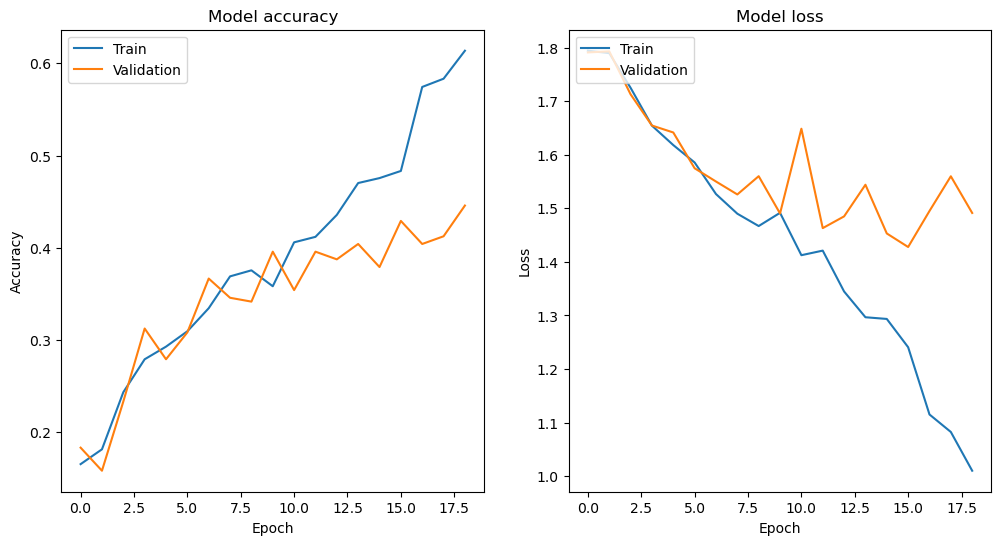

In [534]:
# Plot learning curves
def plot_learning_curves(v2_history):
    plt.figure(figsize=(12, 6))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(v2_history.history['accuracy'])
    plt.plot(v2_history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(v2_history.history['loss'])
    plt.plot(v2_history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_learning_curves(v2_history)

### Model Performance

In [585]:
from sklearn.metrics import precision_score

def evaluate_model(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)
    
    # Convert probabilities to class labels
    if len(y_pred_prob.shape) > 1 and y_pred_prob.shape[1] > 1:
        y_pred = np.argmax(y_pred_prob, axis=1)
    else:
        y_pred = y_pred_prob.round().astype(int)
    
    # Convert y_test to one-hot encoded format if needed
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_label = np.argmax(y_test, axis=1)
    else:
        y_test_label = y_test
    
    accuracy = accuracy_score(y_test_label, y_pred)
    precision = precision_score(y_test_label, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test_label, y_pred, average='weighted')
    f1 = f1_score(y_test_label, y_pred, average='weighted')
    cm = confusion_matrix(y_test_label, y_pred)
    return accuracy, precision, recall, f1, cm

# Assuming you have defined v1_model and mlp

# Evaluate v2_model and mlp
models = [v2_model, mlp]  # Only v1_model and mlp
X_tests = [v2_X_test, mlp_X_test]  # Test data for v1_model and mlp
y_tests = [v2_y_test, mlp_y_test]  # Test labels for v1_model and mlp

for i, model in enumerate(models):
    print(f"Model {i+1}:")
    accuracy, precision, recall, f1, cm = evaluate_model(model, X_tests[i], y_tests[i])
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("=" * 50)


Model 1:
2/4 [==============>...............] - ETA: 0s

4/4 [==============================] - 1s 203ms/step
Confusion Matrix:
[[13  0  1  0  0  0]
 [ 2  8  2  3  0  7]
 [ 2  1 11  2  0  5]
 [ 7  0  5  3  2  4]
 [ 0  2  1  1  6 14]
 [ 2  2  3  0  1 10]]
Accuracy: 0.4250
Precision: 0.4840
Recall: 0.4250
F1 Score: 0.4066
Model 2:
4/4 [==============================] - 0s 10ms/step
Confusion Matrix:
[[6 1 4 0 1 2]
 [3 8 3 1 0 7]
 [4 5 6 0 1 5]
 [1 7 4 1 0 8]
 [3 6 4 0 2 9]
 [1 2 6 0 0 9]]
Accuracy: 0.2667
Precision: 0.3496
Recall: 0.2667
F1 Score: 0.2354


### Model Performance

The first iteration got an accuracy of 42% and has a somewhat off misclassification count. This suggests significant misclassification errors occurring in the model. Occurs when the model architecture is not complex enough. Because the model has a very simple architecture it may struggle to learn specific and detailed patterns and features required for an accurate classification. Furthermore, the dataset is very small and can therefore not effectively train the model.

To address this issue, I will apply data augmentation in the next step in the hope to improve its performance


3/8 [==========>...................] - ETA: 1s

8/8 [==============================] - 2s 193ms/step


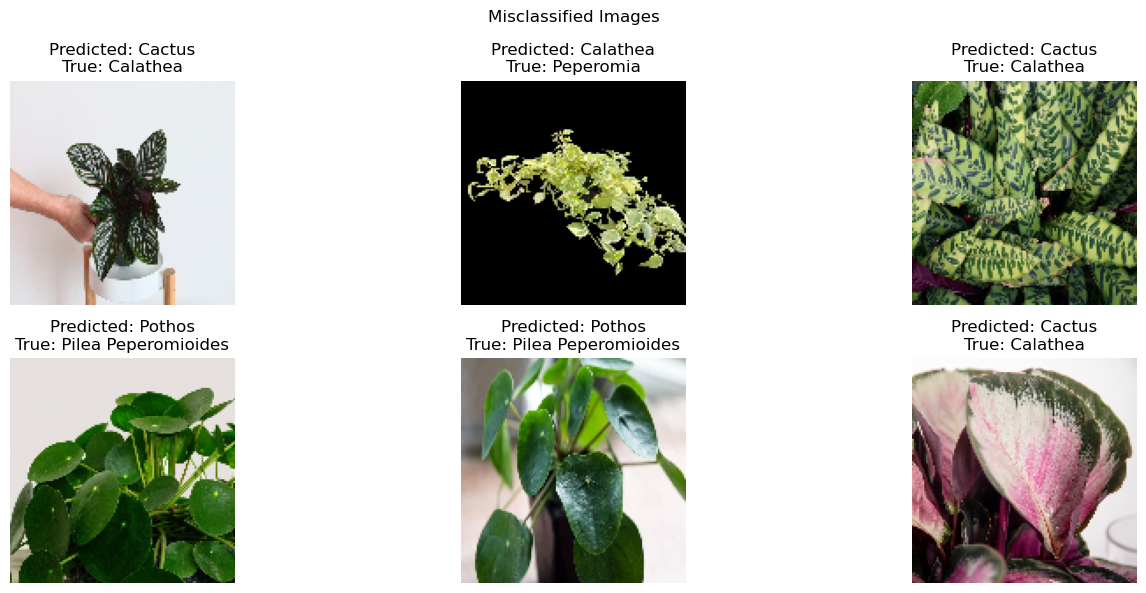

In [947]:
import numpy as np
import matplotlib.pyplot as plt

def plot_wrong_classifications(images, predicted_labels, true_labels, class_names, num_examples=6):
    # Find the indices of misclassified images
    misclassified_indices = np.where(predicted_labels != true_labels)[0]
    num_misclassified = len(misclassified_indices)
   
    if num_misclassified == 0:
        print("No misclassifications found.")
        return
   
    num_examples = min(num_examples, num_misclassified)
   
    # Shuffle the indices of misclassified images
    np.random.shuffle(misclassified_indices)
    
    # Create subplots to display the misclassified images
    fig, axes = plt.subplots(2, num_examples // 2, figsize=(15, 6))
    fig.suptitle('Misclassified Images')
   
    # Iterate over each misclassified image
    for i, idx in enumerate(misclassified_indices[:num_examples]):
        # Compute the row and column indices
        row = i // (num_examples // 2)
        col = i % (num_examples // 2)
        
        # Display the image
        axes[row, col].imshow(images[idx])
        
        # Set the title of the subplot with predicted and true labels
        axes[row, col].set_title(f"Predicted: {class_names[predicted_labels[idx]]}\nTrue: {class_names[true_labels[idx]]}")
        
        # Hide axis ticks
        axes[row, col].axis('off')
   
    # Adjust layout
    plt.tight_layout()
   
    # Show the plot
    plt.show()

# Make predictions on the validation set
v2_predictions = v2_model.predict(v2_X_val)
v2_true_labels = np.argmax(v2_y_val, axis=1)
v2_predicted_labels = np.argmax(v2_predictions, axis=1)

# Plot misclassified images
plot_wrong_classifications(v2_X_val, v2_predicted_labels, v2_true_labels, class_names, num_examples=6)


Even with the implementation of data augmentation, this iteration did not perform as well as I hoped it would. The data augmentation only led to marginal improvement, which suggests that the model may still be struggling to learn the underlying patterns in the data effectively. 

To address this issue, I will only apply transfer learning as the current model has limited capacity to capture the dataset’s complexity.


### MLP From Scratch

Importing libaries

In [908]:
from skimage import io as ski_io
import os
import numpy as np
import skimage as ski
import random
from sklearn import preprocessing

In [ ]:
# Defining the directory containing the dataset
datasets = str("C:/../GitHub/Google-Image-Scraper/photos")

# Folder paths to the images of each class are stored
folder_paths = [
    r"C:/../GitHub/Google-Image-Scraper/photos/Cactus",
    r"C:/../GitHub/Google-Image-Scraper/photos/Calathea",
    r"C:/../GitHub/Google-Image-Scraper/photos/Monstera Minima",
    r"C:/../GitHub/Google-Image-Scraper/photos/Peperomia",
    r"C:/../GitHub/Google-Image-Scraper/photos/Pilea Peperomioides",
    r"C:/../GitHub/Google-Image-Scraper/photos/Pothos"
]

# Class labels for the images (same order as folder_paths)
class_names = [
    "Cactus", "Calathea", "Monstera Minima", "Peperomia", "Pilea Peperomioides", "Pothos"
]

In [910]:
# Target size to resize the images
target_size = (16, 16)

# Arrays to store the images (X) and class labels (y)
X = []
y = []

Preprocessing the dataset to ensure that all classes contain approximately 200 images and that they are all in RGB format

In [912]:
import os
from PIL import Image
import numpy as np

# Function that makes sure that the images are in RGB format
def is_rgb_image(image_path):
    try:
        with Image.open(image_path) as img:
            if img.mode == 'RGB':
                return True
            elif img.mode == 'RGBA':
                # Convert RGBA to RGB
                img = img.convert("RGB")
                return True
            else:
                return False
    except Exception as e:
        print(f"Error: {e}")
        return False
# Specify the number of images to be loaded
num_images_per_folder = 200
target_size = (16, 16)

for i in range(len(folder_paths)):
    # List all files in the folder
    files = os.listdir(folder_paths[i])
    # Select 20 files randomly
    files_to_load = random.sample(files, min(num_images_per_folder, len(files)))
    for filename in files_to_load:
        file_extension = os.path.splitext(filename)[1]
        # Check if the file extension is an image extension
        if file_extension.lower() in ['.jpg', '.jpeg', '.png']:
            image_filename = os.path.join(folder_paths[i], filename)
            # Check if the image is in RGB format
            if is_rgb_image(image_filename):
                # Read the image file using scikit-image
                image = ski_io.imread(image_filename, as_gray=True)
                # Resize the image to the target_size
                image_resized = ski_transform.resize(image, target_size)
                if image_resized.shape == (16, 16):
                    # Insert the image into array X
                    X.append(image_resized)
                    # Insert the class label into array y
                    y.append(class_names[i])

# Convert arrays into numpy arrays
X = np.array(X)
y = np.array(y)

In [913]:
# Initialize LabelEncoder with class names
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(class_names)

# Encode class labels
y_integer_encoded = label_encoder.transform(y)

# Convert integer-encoded labels into one-hot encoded vectors
def to_one_hot(labels, num_classes):
    num_samples = len(labels)
    one_hot_encoded = np.zeros((num_samples, num_classes))
    one_hot_encoded[np.arange(num_samples), labels] = 1
    return one_hot_encoded

y_onehot_encoded = to_one_hot(y_integer_encoded, len(class_names))

# Split the data into train, test, and validation sets
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y_onehot_encoded, test_size=0.1, random_state=0)
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val, test_size=2/9, random_state=0)

# Reshape the input data
X_train_reshaped = X_train.reshape(-1, 16*16)
X_test_reshaped = X_test.reshape(-1, 16*16)
X_val_reshaped = X_val.reshape(-1, 16*16)

The following function iterates over the layers of the architecture, except the output layer, and initializes the weights and biases for each layer randomely using a Gaussian distribution. 

In [914]:
from copy import deepcopy

def initializer(mlps_architecture):
    weights = []
    biases = []

    for l in range(0, len(mlps_architecture)-1):
        w = np.random.randn(mlps_architecture[l], mlps_architecture[l+1])
        weights.append(w)
        b = np.random.randn(1, mlps_architecture[l+1])
        biases.append(b)

    return weights, biases

The softmax function converts the raw scores (logits) of the neural network's output layer into probabilities for multi-class classification tasks. 

In [915]:
def softmax(x):
    # Subtracting the maximum value from each element for numerical stability
    exp_scores = np.exp(x - np.max(x, axis=1, keepdims=True))
    # Compute softmax probabilities
    softmax_probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    return softmax_probs

In [916]:
def predict(X, weights, biases):
    '''
    This function is used to make predictions using the mlps_architecture with given weights and biases. 

    '''
    layer_input = X
    for i in range(len(weights)):
        layer_output = sigmoid(np.dot(layer_input, weights[i]) + biases[i])
        layer_input = layer_output
    y_pred = layer_output

    return y_pred

In [917]:
def accuracy(y_pred_binary, y):
    '''
    Calculates the accuracy of mlps_architecture

    '''
    return sum(y_pred_binary == y)/len(y)

In [918]:
def loss_function(X, y, weights, biases):
    losses = []
    for i in range(len(X)):
        prediction = predict(X[i], weights, biases)
        # Avoid numerical instability by clipping probabilities
        epsilon = 1e-15
        prediction = np.clip(prediction, epsilon, 1 - epsilon)
        # Cross-entropy loss calculation
        loss = -np.sum(y[i] * np.log(prediction))
        losses.append(loss)

    return np.mean(losses)

In [919]:
def weight_update(weights, layer_id, i, j, new_param):
    # It is important to create a copy of the weights and update the copy
    new_w = deepcopy(weights)

    layer_w = weights[layer_id]
    new_layer_w = layer_w.copy()
    new_layer_w[i, j] = new_param
    new_w[layer_id] = new_layer_w

    return new_w

In [920]:
def bias_update(biases, layer_id, j, new_param):
    '''
    Given a single bias defined by (layer_id, j)
    updates it with a new parameter (new_param)

    Arguments
        biases: list of np.arrays()
        layer_id: integer
        j: integer
        new_param: float
    Return
        new_b: list of np.arrays()
               where only a single value is changed

    '''

    # It is important to create a copy and update the copy
    new_b = deepcopy(biases)

    layer_b = biases[layer_id]
    new_layer_b = layer_b.copy()
    new_layer_b[0, j] = new_param
    new_b[layer_id] = new_layer_b

    return new_b

In [921]:
def gradient_estimator(X, y, weights, biases):
    eps = 1e-4
    loss_val = loss_function(X, y, weights, biases)

    # partial derivatives for weights
    w_pds = []
    for layer_id, layer_w in enumerate(weights):
        pd_array = np.zeros(layer_w.shape)

        # Calculate the partial derivative (pd) for each weight
        # and save those values into pd_array

        for i in range(layer_w.shape[0]):
            for j in range(layer_w.shape[1]):

                wij = layer_w[i, j]

                wij_plus = wij + eps
                w_plus = weight_update(weights, layer_id, i, j, wij_plus)
                loss_plus = loss_function(X, y, w_plus, biases)

                pd = (loss_plus - loss_val)/eps
                pd_array[i, j] = pd

        w_pds.append(pd_array)

    # partial derivatives for biases
    b_pds = []
    for layer_id, layer_b in enumerate(biases):
        pd_array = np.zeros(layer_b.shape)

        # Calculate the partial derivative (pd) for each bias
        # and save those values into pd_array

        for j in range(layer_b.shape[1]):
            i = 0
            bij = layer_b[i, j]

            bij_plus = bij + eps
            b_plus = bias_update(biases, layer_id, j, bij_plus)
            loss_plus = loss_function(X, y, weights, b_plus)

            pd = (loss_plus - loss_val)/eps
            pd_array[i, j] = pd

        b_pds.append(pd_array)

    return w_pds, b_pds    

In [922]:
def one_step_gradient_descent(X, y, weights, biases, lr):
    '''
    This function executes one step of gradient decent and updates weights and biases.

    First estimate the gradient using the gradient_estimator function implemented
    in the previous task.

    Then, update the params by:
    w = w - lr * w_pds
    b = b - lr * b_pds

    Arguments:
        X: input data
        y: labels
        weights: NN weights
        biases: NN biases
        lr: learning rate, a float
    Returns:
        new_w: updated weights, same size as weights
        new_b: updated biases, same size as biases

    '''
    w_pds, b_pds = gradient_estimator(X, y, weights, biases)

    new_w = []
    # For each weight array in weights list
    # use gradient descent update rule
    # append the array to new_w list

 
    for layer_id, layer_w in enumerate(weights):
        layer_new_w = layer_w - lr*w_pds[layer_id]
        new_w.append(layer_new_w)


    new_b = []
    # For each bias array in biases list
    # use gradient descent update rule
    # append the array to new_b list

    for layer_id, layer_b in enumerate(biases):
        layer_new_b = layer_b - lr*b_pds[layer_id]
        new_b.append(layer_new_b)
    return new_w, new_b

In [923]:
def gradient_descent(X, y, weights, biases, epoch, lr):
    errors = []

    for i in range(epoch):
        weights, biases = one_step_gradient_descent(X, y, weights, biases, lr)
        error = loss_function(X, y, weights, biases)
        errors.append(error)

    plt.figure(dpi=200)
    plt.plot(errors)
    plt.xlabel('# epochs')
    plt.ylabel('loss')

    return weights, biases

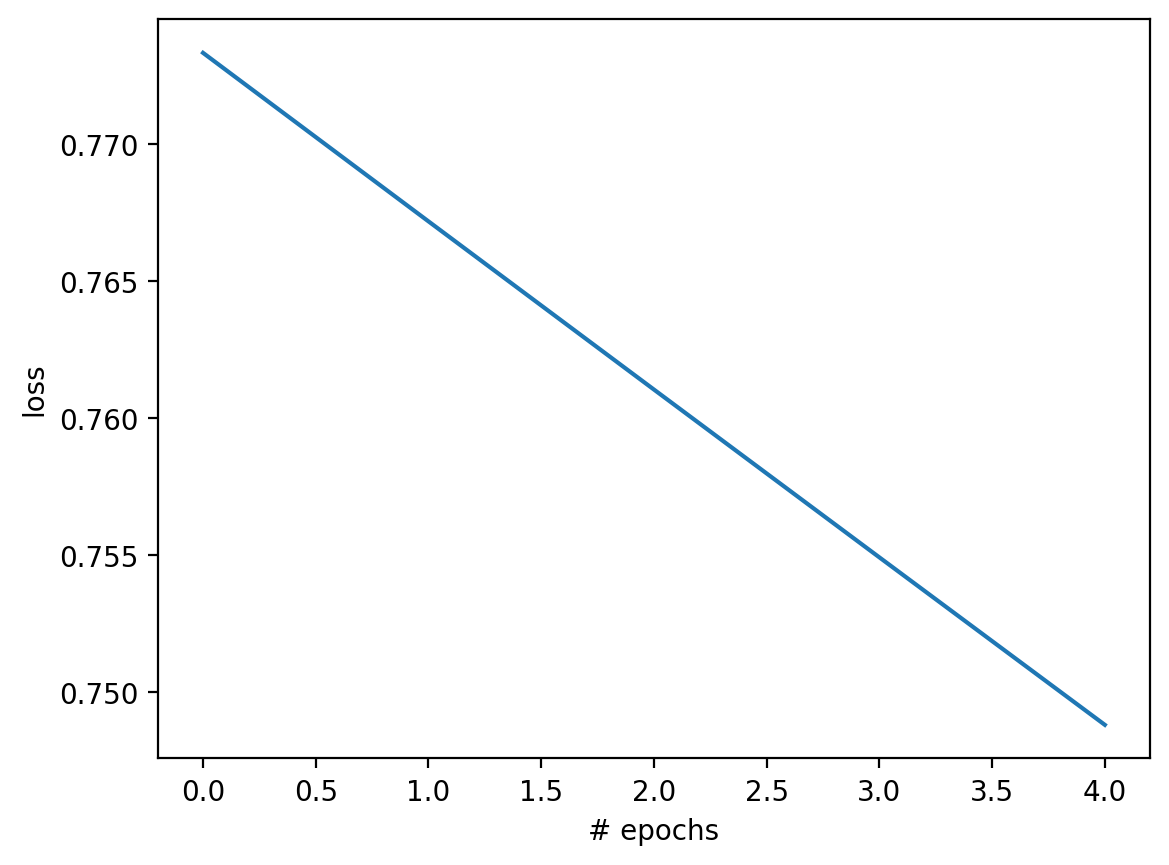

In [925]:
# Define MLP architecture
mlps_architecture = [X_train_reshaped.shape[1], 64, 6]

# Initialize weights and biases
weights, biases = initializer(mlps_architecture)

# Train the MLP using gradient descent
trained_weights, trained_biases = gradient_descent(X_train_reshaped, y_train, weights, biases, epoch=5, lr=0.01)


In [932]:
print("Test Accuracies by Class:")
for i, class_accuracy in enumerate(test_accuracy):
    print(f"Class {i}: {class_accuracy:.2f}")

Test Accuracies by Class:
Class 0: 0.27
Class 1: 0.27
Class 2: 0.08
Class 3: 0.18
Class 4: 0.87
Class 5: 0.15
